# 02. Limpieza y Enriquecimiento de Datos (Feature Engineering)

Una vez que entendieron los datos, vamos a prepararlos para que los algoritmos de Machine Learning puedan procesarlos correctamente. En la vida real, lo mejor es empaquetar esto automatizado en Scikit-Learn Pipelines o en scripts de Python (`src/features/build_features.py`). Aquí puedes experimentar con las rutinas de limpieza.

### Instrucciones Generales:
1. **Solvertar problema de calidad:**: Solucionar problema de calidad encontrados en el EDA: consistencia, sensibilidad, precision y completitud. Documenta cada decision tomada.
2. **Codificación Categórica:** El campo `ocean_proximity` es de texto. Conviértelo en variable numerica, ya que los algoritmos clasicos no entienen el texto. Documenta porque usaste codificacion Ordinal o Nominal.
3. **Enriquecimiento (Feature Engineering):** Como pudiste notar en tu análisis, `total_rooms` no significa mucho si hay muchos hogares en un distrito. Agrega nuevas métricas útiles, por ejemplo:
   - `rooms_per_household = total_rooms / households`
   - `bedrooms_per_room = total_bedrooms / total_rooms`
   - `population_per_household = population / households`
4. **Escalado de Variables:** Aplica un `StandardScaler` o `MinMaxScaler` para evitar que las variables numéricas grandes pesen más en algoritmos basados en distancias o gradientes.


In [1]:
import pandas as pd

housing = pd.read_csv("../data/interim/train_set.csv")

# 1. Solventar problema de calidad

In [2]:
# Debido a que la cantidad de datos faltantes es muy pequeña (1%), se opta por imputar los valores faltantes con la mediana.

print(f"Imputando valores faltantes con la mediana: {housing['total_bedrooms'].median()}")
housing.fillna({'total_bedrooms': housing['total_bedrooms'].median()}, inplace=True)
housing.info()

Imputando valores faltantes con la mediana: 434.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.3+ MB


# 2. Codificación Categórica

In [3]:
# Ya que ocean_proximity no es una variable ordinal sino categórica por ubicación, optamos por un encoding one-hot.

housing = pd.get_dummies(housing, columns=['ocean_proximity'], drop_first=True)

housing.sample(5, random_state=1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
11418,-118.21,34.18,14.0,2672.0,335.0,1113.0,318.0,12.1579,500001.0,False,False,False,False
6821,-122.01,37.57,14.0,16199.0,2993.0,8117.0,2847.0,5.8322,281800.0,False,False,True,False
9138,-117.12,32.96,15.0,2869.0,405.0,1526.0,402.0,6.0175,238300.0,False,False,False,False
4175,-117.57,34.07,4.0,2152.0,580.0,1083.0,441.0,3.1458,118800.0,True,False,False,False
15220,-121.35,38.03,16.0,3158.0,515.0,1596.0,528.0,4.1739,131300.0,True,False,False,False


In [4]:
# Probamos el mismo proceso con el set de test para asegurarnos que no haya problemas.
# Evitamos usar pd.get_dummies directamente para mantener control total sobre el proceso y evitar columnas inesperadas o faltantes.

test = pd.read_csv("../data/interim/test_set.csv").head()

categories = ["INLAND", "ISLAND", "NEAR BAY", "NEAR OCEAN"]

for category in categories:
    test[f"ocean_proximity_{category}"] = test["ocean_proximity"].apply(lambda x: 1 if x == category else 0)

# test.drop(columns=["ocean_proximity"], inplace=True)

test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-121.95,37.11,21.0,2387.0,357.0,913.0,341.0,7.7360,397700.0,<1H OCEAN,0,0,0,0
1,-118.01,33.89,36.0,1589.0,265.0,804.0,272.0,4.6354,202900.0,<1H OCEAN,0,0,0,0
2,-118.18,33.74,30.0,5915.0,1750.0,2136.0,1503.0,4.0968,310000.0,NEAR OCEAN,0,0,0,1
3,-122.48,37.74,52.0,2166.0,423.0,1072.0,370.0,4.1310,314300.0,NEAR OCEAN,0,0,0,1
4,-122.39,37.78,5.0,1405.0,515.0,725.0,392.0,3.6037,187500.0,NEAR BAY,0,0,1,0


# 3. Enriquecimiento

In [5]:
# Agregamos variables analizadas en el análisis exploratorio, que podrían ser útiles para el modelo.

housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"] / housing["households"]

housing.sample(5, random_state=1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
11418,-118.21,34.18,14.0,2672.0,335.0,1113.0,318.0,12.1579,500001.0,False,False,False,False,8.402516,0.125374,3.500000
6821,-122.01,37.57,14.0,16199.0,2993.0,8117.0,2847.0,5.8322,281800.0,False,False,True,False,5.689849,0.184764,2.851071
9138,-117.12,32.96,15.0,2869.0,405.0,1526.0,402.0,6.0175,238300.0,False,False,False,False,7.136816,0.141164,3.796020
4175,-117.57,34.07,4.0,2152.0,580.0,1083.0,441.0,3.1458,118800.0,True,False,False,False,4.879819,0.269517,2.455782
15220,-121.35,38.03,16.0,3158.0,515.0,1596.0,528.0,4.1739,131300.0,True,False,False,False,5.981061,0.163078,3.022727


# 4. Escalado de Variables

In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler

X_train = housing.drop(columns=['median_house_value'])
y_train = housing['median_house_value']

log_cols = ['total_bedrooms', 'total_rooms', 'households', 'population']
X_train_transformed = X_train.copy()
X_train_transformed[log_cols] = X_train_transformed[log_cols].apply(np.log1p)

numeric_cols = X_train_transformed.select_dtypes(include=['number']).columns

print("Estadísticas antes de la estandarización:")
display(X_train_transformed.describe().iloc[1:])

scaler = StandardScaler()
X_train_scaled = X_train_transformed.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_transformed[numeric_cols])

print("Estadísticas después de la estandarización:")
display(X_train_scaled[numeric_cols].describe().iloc[1:])

X_train_scaled.head()

Estadísticas antes de la estandarización:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household
mean,-119.573125,35.637746,28.577156,7.631601,6.056775,7.027240,5.985629,3.870428,5.441010,0.213727,2.995974
std,2.000624,2.133294,12.585738,0.746605,0.721562,0.734835,0.725822,1.891936,2.574143,0.066077,4.457373
min,-124.350000,32.550000,1.000000,1.098612,0.693147,1.386294,0.693147,0.499900,0.888889,0.037066,0.692308
25%,-121.800000,33.930000,18.000000,7.277939,5.697093,6.669498,5.634790,2.562500,4.443636,0.175058,2.433426
50%,-118.510000,34.260000,29.000000,7.661998,6.075346,7.063048,6.013715,3.538500,5.235573,0.203120,2.822316
75%,-118.010000,37.720000,37.000000,8.056744,6.466145,7.454141,6.403574,4.750000,6.053843,0.239844,3.286385
max,-114.490000,41.950000,52.000000,10.579514,8.734077,9.699288,8.586533,15.000100,141.909091,2.818182,502.461538


Estadísticas después de la estandarización:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household
mean,-4.837216e-15,-2.580838e-15,-1.473843e-17,1.218879e-16,-3.900842e-16,1.639515e-16,-3.801868e-16,7.611267e-17,2.671205e-16,6.239626e-17,5.514807e-17
std,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00
min,-2.387765e+00,-1.447452e+00,-2.191210e+00,-8.750529e+00,-7.433584e+00,-7.676715e+00,-7.291927e+00,-1.781577e+00,-1.768456e+00,-2.673650e+00,-5.168373e-01
25%,-1.113124e+00,-8.005453e-01,-8.404335e-01,-4.737089e-01,-4.984910e-01,-4.868483e-01,-4.833834e-01,-6.913383e-01,-3.874701e-01,-5.852220e-01,-1.262100e-01
50%,5.314128e-01,-6.458502e-01,3.359809e-02,4.071407e-02,2.573860e-02,4.873059e-02,3.869631e-02,-1.754490e-01,-7.981016e-02,-1.605265e-01,-3.896095e-02
75%,7.813423e-01,9.761041e-01,6.692575e-01,5.694519e-01,5.673562e-01,5.809656e-01,5.758400e-01,4.649198e-01,2.380800e-01,3.952682e-01,6.515484e-02
max,2.540847e+00,2.959014e+00,1.861119e+00,3.948545e+00,3.710540e+00,3.636367e+00,3.583497e+00,5.882868e+00,5.301656e+01,3.941670e+01,1.120572e+02


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
0,-1.423037,1.013606,1.861119,0.638538,1.331502,0.457313,1.317893,-0.936491,False,False,True,False,-0.866027,1.846624,-0.330204
1,0.596394,-0.702103,0.907630,-0.064085,-0.255920,-0.713720,-0.144801,1.171942,False,False,False,False,0.024550,-0.508121,-0.253616
2,-1.203098,1.276119,0.351428,-0.861510,-0.931729,-0.944405,-0.919687,-0.759789,True,False,False,False,-0.041193,-0.202155,-0.051041
3,1.231216,-0.884924,-0.919891,0.944663,0.957413,0.671649,0.929933,-0.850281,True,False,False,False,-0.034858,-0.149006,-0.141475
4,0.711362,-0.875549,0.589800,1.004887,1.445870,0.720167,1.490342,-0.180365,False,False,False,True,-0.666554,0.963208,-0.306148


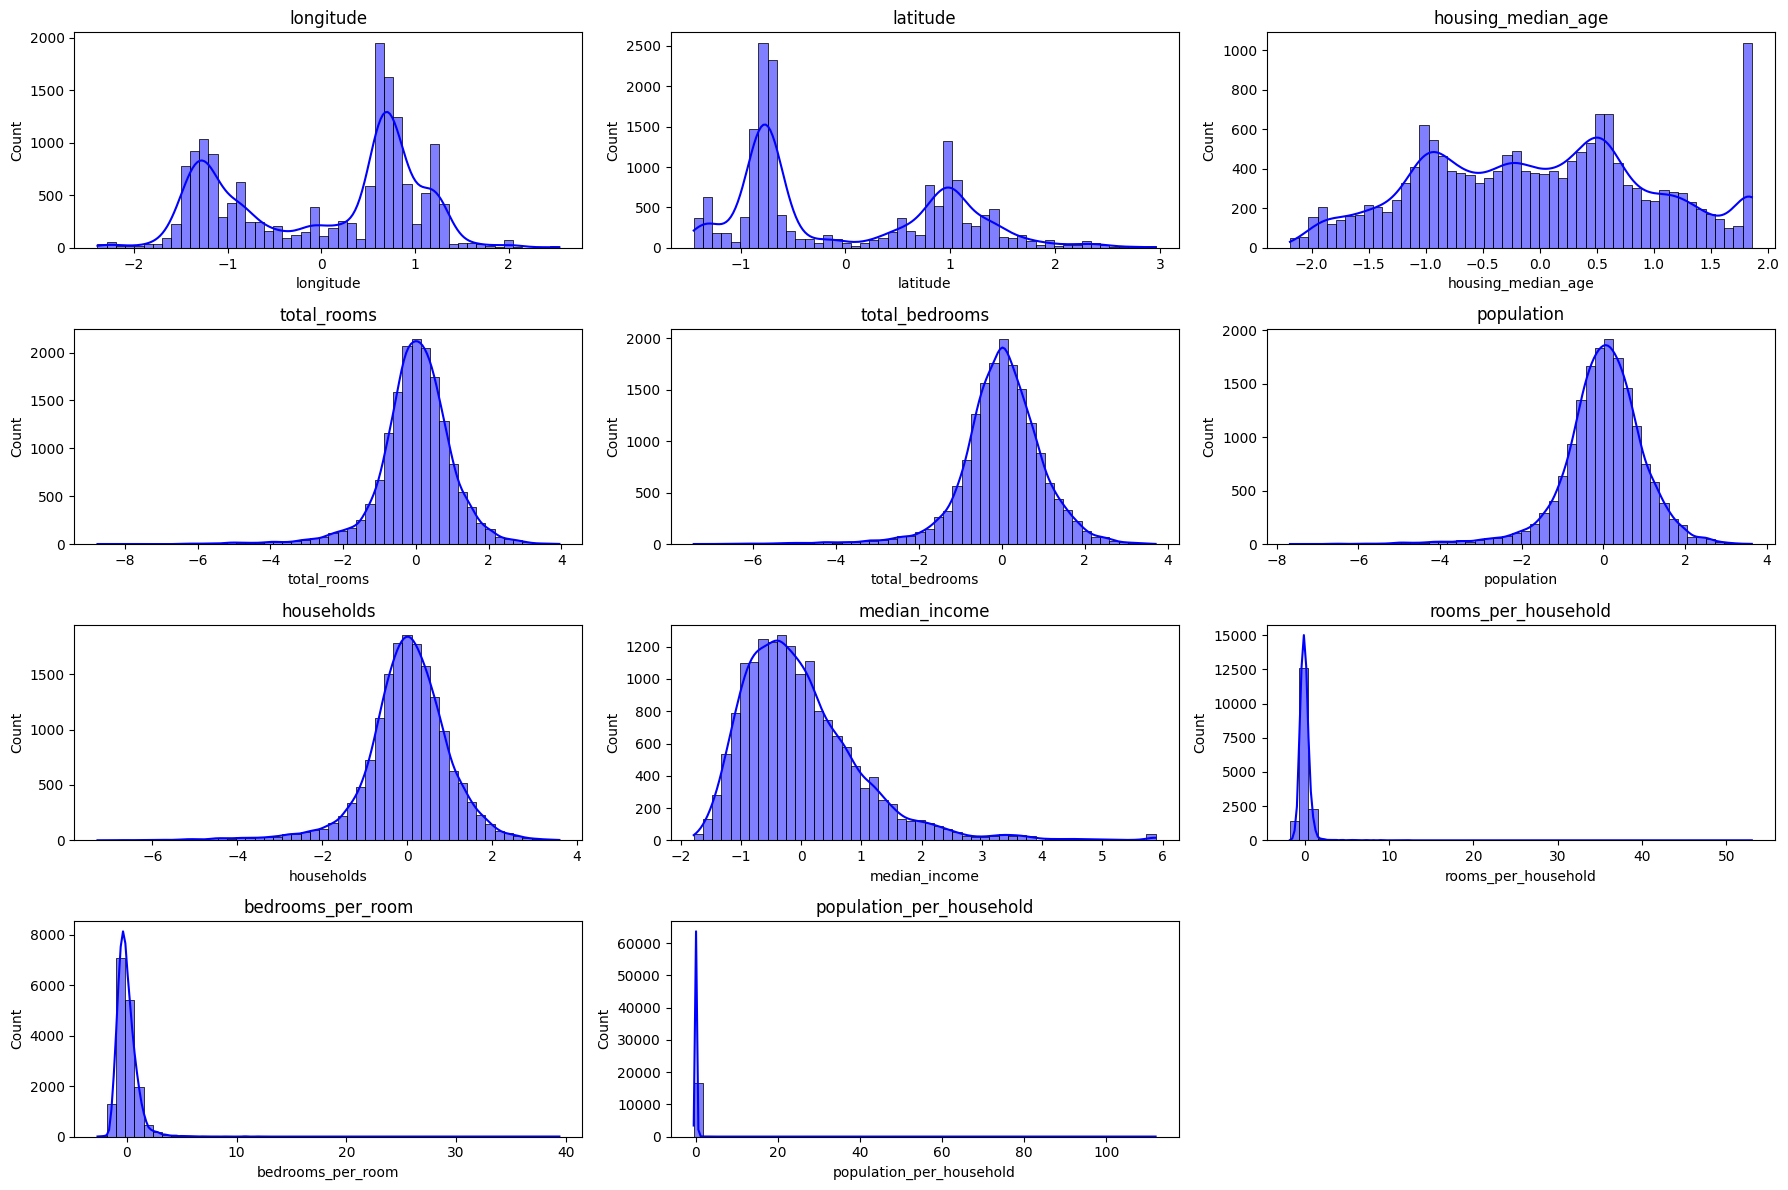

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 3, figsize=(18, 4 * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(X_train_scaled[col], bins=50, kde=True, ax=axes[i], color='blue')
    axes[i].set_title(col)

# Apagar los ejes no utilizados
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()